/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


OR Historical Data:
            OR_Pages
Date                
2026-04-20         8
2026-04-21        10
2026-04-22         4
2026-04-23         8
2026-04-24         9

Forecasted OR Pages for Next 3 Work Days:
2026-04-27    8.0
2026-04-28    8.0
2026-04-29    8.0
Freq: B, dtype: float64


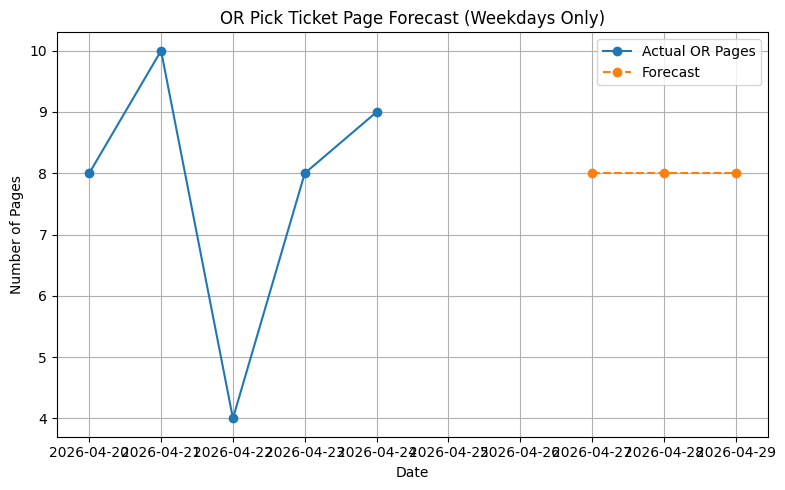

In [3]:
# Import pandas so we can work with dates, tables, and time series data
import pandas as pd

# Import matplotlib so we can create a graph of the actual and predicted values
import matplotlib.pyplot as plt

# Import Simple Exponential Smoothing, which is the forecasting model used here
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Store the actual OR page counts from the Excel data
or_pages = [8, 10, 4, 8, 9]

# Create weekday-only dates starting on April 20, 2026
# bdate_range automatically skips Saturdays and Sundays
dates = pd.bdate_range(start="2026-04-20", periods=len(or_pages))

# Create a dataframe that connects each date with its OR page count
or_df = pd.DataFrame({
    "Date": dates,
    "OR_Pages": or_pages
})

# Set the Date column as the index so Python treats the data like a time series
or_df.set_index("Date", inplace=True)

# Create and train the forecasting model using the OR page data
model = SimpleExpSmoothing(or_df["OR_Pages"]).fit()

# Create the next 3 weekday dates after the last recorded OR date
forecast_dates = pd.bdate_range(
    start=or_df.index[-1] + pd.Timedelta(days=1),
    periods=3
)

# Forecast the next 3 OR page values using the trained model
forecast_values = model.forecast(3)

# Combine the forecasted values with the correct weekday-only dates
forecast = pd.Series(forecast_values.values, index=forecast_dates)

# Print the original OR data to the screen
print("OR Historical Data:")
print(or_df)

# Print the predicted OR pages for the next 3 workdays
print("\nForecasted OR Pages for Next 3 Work Days:")
print(forecast)

# Create a new graph
plt.figure(figsize=(8, 5))

# Plot the actual OR page data
plt.plot(or_df.index, or_df["OR_Pages"], marker="o", label="Actual OR Pages")

# Plot the forecasted OR page data with a dashed line
plt.plot(forecast.index, forecast, marker="o", linestyle="--", label="Forecast")

# Add a title to the graph
plt.title("OR Pick Ticket Page Forecast (Weekdays Only)")

# Label the x-axis
plt.xlabel("Date")

# Label the y-axis
plt.ylabel("Number of Pages")

# Add a legend so the viewer knows which line is actual vs. forecasted
plt.legend()

# Add grid lines to make the chart easier to read
plt.grid(True)

# Adjust spacing so nothing overlaps
plt.tight_layout()

# Display the graph
plt.show()